
# Detector-level closed-loop AO simulation

This notebook combines the detector-level Shack-Hartmann WFS model with a closed-loop adaptive optics controller.

Unlike the earlier slope-level closed-loop notebook, the WFS measurement is not taken directly from analytic wavefront gradients. Instead, each residual wavefront is converted into lenslet focal-plane spots, detector noise is added, centroid shifts are measured, and these centroid shifts are used to update the deformable mirror.

The simulated control chain is:

```text
frozen-flow atmosphere
→ current DM correction
→ residual wavefront
→ lenslet spot images
→ photon/read-noise detector model
→ centroid shifts
→ detector-level response matrix
→ DM command update
→ corrected residual
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))

from phase_screen import fourier_phase_screen
from reconstruction import rms
from psf_tools import compute_psf_from_phase, strehl_ratio

from ao_closed_loop import (
    actuator_centers_on_pupil,
    gaussian_influence_functions,
    synthesize_dm_phase,
    build_dm_detector_response_matrix,
    reconstruct_dm_delta,
)

from shwfs_detector import measure_centroid_shifts


## 1. Generate a toy atmospheric phase screen

We generate a Kolmogorov/von-Kármán-like phase screen and normalize its RMS.  This keeps the experiment numerically stable and easy to interpret.


In [2]:
N = 256
D = 1.0
delta = D / N

# Large screen for frozen-flow cropping.
# This avoids repeatedly wrapping the same pupil-sized screen.
N_large = 4 * N
D_large = D * (N_large / N)

phase_large, X_large, Y_large, pupil_large = fourier_phase_screen(
    N=N_large,
    delta=delta,
    diameter=D_large,
    r0=0.25,
    L0=10.0,
    target_rms_rad=1.0,
    seed=4,
    mask_output=False,
)

# Pupil-coordinate grid for the science aperture.
x = (np.arange(N) - N / 2 + 0.5) * delta
X, Y = np.meshgrid(x, x)
pupil_mask = X**2 + Y**2 <= (D / 2)**2


def crop_frozen_flow_phase(
    phase_large,
    step,
    pupil_mask,
    crop_size=256,
    wind_shift_per_step=(2, 0),
    remove_piston=True,
):
    """
    Crop a pupil-sized atmospheric phase screen from a larger frozen-flow screen.

    Parameters
    ----------
    phase_large : 2D array
        Large atmospheric phase screen.
    step : int
        Loop step.
    pupil_mask : 2D bool array
        Science pupil mask for the cropped aperture.
    crop_size : int
        Size of the cropped pupil screen.
    wind_shift_per_step : tuple[int, int]
        Pixel shift per time step as (dx, dy).
    remove_piston : bool
        Remove mean phase inside pupil.

    Returns
    -------
    phase_crop : 2D array
        Cropped atmospheric phase screen with NaNs outside the pupil.
    """
    dx_pix, dy_pix = wind_shift_per_step

    n_large = phase_large.shape[0]
    center = n_large // 2

    x0 = center - crop_size // 2 + step * dx_pix
    y0 = center - crop_size // 2 + step * dy_pix

    x1 = x0 + crop_size
    y1 = y0 + crop_size

    if x0 < 0 or y0 < 0 or x1 > n_large or y1 > n_large:
        raise ValueError(
            "Frozen-flow crop reached the edge of the large phase screen. "
            "Increase N_large or reduce n_steps / wind_shift_per_step."
        )

    crop = phase_large[y0:y1, x0:x1].copy()
    crop = np.where(pupil_mask, crop, np.nan)

    if remove_piston:
        crop[pupil_mask] -= np.nanmean(crop[pupil_mask])

    return crop


# Normalize the large screen once using the first science-pupil crop.
phase0_raw = crop_frozen_flow_phase(
    phase_large,
    step=0,
    pupil_mask=pupil_mask,
    crop_size=N,
    wind_shift_per_step=(2, 0),
)
scale = 1.0 / rms(phase0_raw, pupil_mask)
phase_large *= scale

phase0 = crop_frozen_flow_phase(
    phase_large,
    step=0,
    pupil_mask=pupil_mask,
    crop_size=N,
    wind_shift_per_step=(2, 0),
)

print(f"Initial atmospheric phase RMS: {rms(phase0, pupil_mask):.4f} rad")
print(f"Initial uncorrected Strehl: {strehl_ratio(phase0, pupil_mask, pad_factor=4):.4f}")

Initial atmospheric phase RMS: 1.0000 rad
Initial uncorrected Strehl: 0.7048


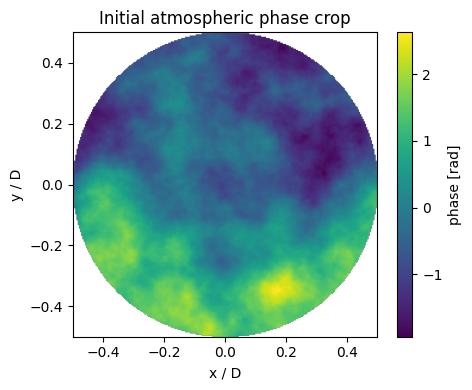

In [3]:
plt.figure(figsize=(5, 4))
plt.imshow(phase0, origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
plt.colorbar(label="phase [rad]")
plt.title("Initial atmospheric phase crop")
plt.xlabel("x / D")
plt.ylabel("y / D")
plt.tight_layout()
plt.show()


## 2. Build a simple Gaussian influence-function deformable mirror

The DM is represented by a square grid of actuators inside the circular pupil.  Each actuator has a Gaussian influence function.  This is not a calibrated real DM, but it captures the basic idea that actuator commands synthesize a smooth corrective surface.


In [4]:
n_actuators_across = 7
centers, pitch = actuator_centers_on_pupil(
    diameter=D,
    n_actuators=n_actuators_across,
    include_edge=True,
)

influence_functions = gaussian_influence_functions(
    X,
    Y,
    pupil_mask,
    centers,
    pitch,
    coupling=0.45,
)

print(f"Number of active actuators: {len(centers)}")
print(f"Actuator pitch: {pitch:.3f} D")

Number of active actuators: 29
Actuator pitch: 0.167 D


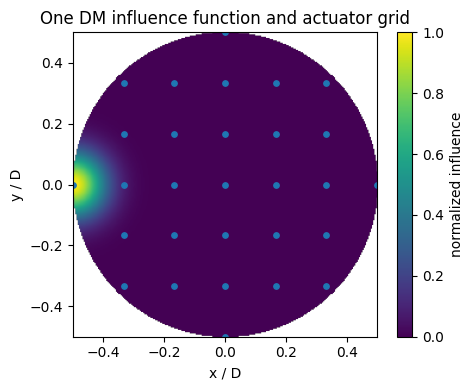

In [5]:
plt.figure(figsize=(5, 4))
plt.imshow(influence_functions[0], origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
plt.scatter(centers[:, 0], centers[:, 1], s=15)
plt.colorbar(label="normalized influence")
plt.title("One DM influence function and actuator grid")
plt.xlabel("x / D")
plt.ylabel("y / D")
plt.tight_layout()
plt.show()


## 3. DM-to-WFS response matrix

The response matrix maps actuator commands to Shack-Hartmann slope vectors.  This is the actuator-space equivalent of the modal response matrix used in earlier notebooks.


In [6]:
# Detector-level SH-WFS configuration
n_lenslets = 10
min_fill = 0.45
pad_factor = 4

centroid_threshold = 0.05
read_noise_e = 3.0
background_e = 0.0
detector_window_size = None
subtract_minimum = False

calibration_amplitude = 0.05  # rad-equivalent DM calibration amplitude

B_det, wfs_centers, lenslet_masks, reference = build_dm_detector_response_matrix(
    influence_functions,
    pupil_mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
    threshold_fraction=centroid_threshold,
    subtract_minimum=subtract_minimum,
    detector_window_size=detector_window_size,
    calibration_amplitude=calibration_amplitude,
)

singular_values = np.linalg.svd(B_det, compute_uv=False)

print(f"Detector-level DM-WFS response matrix shape: {B_det.shape}")
print(f"Valid SH sub-apertures: {len(wfs_centers)}")
print(f"Number of active DM actuators: {influence_functions.shape[0]}")
print(f"Matrix rank: {np.linalg.matrix_rank(B_det)} / {B_det.shape[1]}")
print(f"Condition number: {np.linalg.cond(B_det):.2e}")
print(f"Smallest normalized singular value: {singular_values[-1] / singular_values[0]:.3e}")

Detector-level DM-WFS response matrix shape: (160, 29)
Valid SH sub-apertures: 80
Number of active DM actuators: 29
Matrix rank: 29 / 29
Condition number: 3.67e+00
Smallest normalized singular value: 2.727e-01


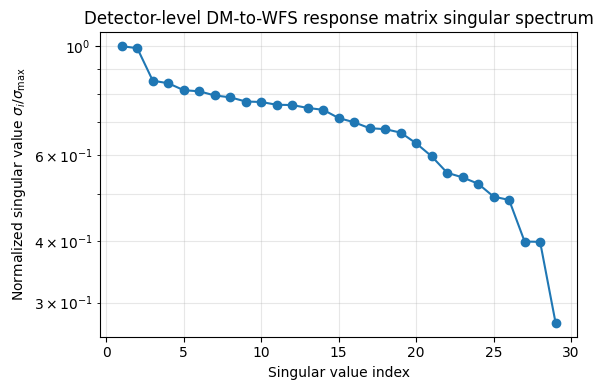

In [7]:
s_norm = singular_values / singular_values[0]

plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(1, len(s_norm) + 1), s_norm, "o-")
plt.xlabel("Singular value index")
plt.ylabel(r"Normalized singular value $\sigma_i / \sigma_{\max}$")
plt.title("Detector-level DM-to-WFS response matrix singular spectrum")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
def fit_dm_to_phase(
    target_phase,
    influence_functions,
    pupil_mask,
    rcond=1e-6,
):
    """
    Compute the best static DM fit to a target phase screen.

    This gives the ideal DM fitting-error floor, independent of WFS noise,
    loop delay, and controller dynamics.
    """
    M = influence_functions[:, pupil_mask].T
    b = target_phase[pupil_mask].copy()
    b -= np.mean(b)

    U, s, Vt = np.linalg.svd(M, full_matrices=False)
    keep = s / s[0] > rcond

    commands = Vt[keep].T @ ((U[:, keep].T @ b) / s[keep])

    dm_phase = synthesize_dm_phase(commands, influence_functions, pupil_mask)

    residual = np.where(pupil_mask, target_phase - dm_phase, np.nan)
    residual[pupil_mask] -= np.nanmean(residual[pupil_mask])

    return commands, dm_phase, residual


fit_commands0, fit_dm0, fit_res0 = fit_dm_to_phase(
    phase0,
    influence_functions,
    pupil_mask,
    rcond=1e-6,
)

print(f"Initial atmosphere RMS: {rms(phase0, pupil_mask):.4f} rad")
print(f"Ideal static DM fitting residual RMS: {rms(fit_res0, pupil_mask):.4f} rad")
print(f"Ideal fitting-error Strehl: {strehl_ratio(fit_res0, pupil_mask, pad_factor=4):.4f}")

Initial atmosphere RMS: 1.0000 rad
Ideal static DM fitting residual RMS: 0.3775 rad
Ideal fitting-error Strehl: 0.8683



## 4. Run the closed loop

The controller is a simple integrator:

```text
commands <- (1 - leak) commands + gain * reconstructed_delta_commands
```

A moderate gain should reduce the residual wavefront.  Too low a gain converges slowly.  Too high a gain may amplify noise or become unstable in more realistic delayed systems.


In [13]:
def run_detector_level_closed_loop_ao(
    phase_large,
    pupil_mask,
    X,
    Y,
    influence_functions,
    response_matrix,
    reference,
    lenslet_masks,
    wfs_centers,
    n_steps=40,
    wind_shift_per_step=(2, 0),
    gain=0.4,
    command_leak=0.01,
    delay_steps=1,
    photons=100_000,
    read_noise_e=3.0,
    background_e=0.0,
    n_lenslets=10,
    min_fill=0.45,
    pad_factor=4,
    threshold_fraction=0.05,
    subtract_minimum=False,
    detector_window_size=None,
    rcond=1e-3,
    compute_strehl=True,
    strehl_pad_factor=4,
    seed=1,
):
    """
    Detector-level closed-loop AO simulation.

    The WFS measurement is obtained from simulated lenslet spots and
    centroid shifts. A configurable measurement delay is included.
    """
    if not (0 <= command_leak < 1):
        raise ValueError("command_leak must satisfy 0 <= command_leak < 1.")

    if delay_steps < 0:
        raise ValueError("delay_steps must be >= 0.")

    n_act = influence_functions.shape[0]
    commands = np.zeros(n_act, dtype=float)

    # Detector-level centroid measurements have shape:
    #     (n_valid_lenslets, 2)
    # not a flattened 1D vector.
    zero_measurement = np.zeros_like(reference, dtype=float)
    measurement_buffer = [zero_measurement.copy() for _ in range(delay_steps)]

    history = {
        "rms_atmosphere": [],
        "rms_before": [],
        "rms_after": [],
        "strehl_before": [],
        "strehl_after": [],
        "command_norm": [],
        "max_abs_command": [],
        "valid_centroids": [],
        "rank": [],
        "cond_eff": [],
    }

    final_state = {}

    for k in range(n_steps):
        atm = crop_frozen_flow_phase(
            phase_large,
            step=k,
            pupil_mask=pupil_mask,
            crop_size=pupil_mask.shape[0],
            wind_shift_per_step=wind_shift_per_step,
        )

        dm_before = synthesize_dm_phase(
            commands,
            influence_functions,
            pupil_mask,
        )

        residual_before = np.where(pupil_mask, atm - dm_before, np.nan)
        residual_before[pupil_mask] -= np.nanmean(residual_before[pupil_mask])

        # Detector-level SH-WFS measurement:
        # residual phase -> lenslet spots -> noisy detector images -> centroid shifts
        _, shifts_current, diag = measure_centroid_shifts(
            residual_before,
            pupil_mask,
            X,
            Y,
            n_lenslets=n_lenslets,
            min_fill=min_fill,
            pad_factor=pad_factor,
            photons=photons,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=threshold_fraction,
            subtract_minimum=subtract_minimum,
            detector_window_size=detector_window_size,
            seed=None if seed is None else seed + k,
            reference=reference,
            masks=lenslet_masks,
            centers=wfs_centers,
            return_diagnostics=True,
        )

        # Apply measurement delay.
        if delay_steps == 0:
            shifts_control = shifts_current
        else:
            shifts_control = measurement_buffer.pop(0)
            measurement_buffer.append(shifts_current)

        # Reconstruct incremental DM command from detector-level centroid shifts.
        delta_commands, _, rank, singular_values_used = reconstruct_dm_delta(
            shifts_control,
            response_matrix,
            rcond=rcond,
        )

        if rank > 0 and len(singular_values_used) >= rank:
            cond_eff = float(singular_values_used[0] / singular_values_used[rank - 1])
        else:
            cond_eff = np.nan

        commands_new = (1.0 - command_leak) * commands + gain * delta_commands

        dm_after = synthesize_dm_phase(
            commands_new,
            influence_functions,
            pupil_mask,
        )

        residual_after = np.where(pupil_mask, atm - dm_after, np.nan)
        residual_after[pupil_mask] -= np.nanmean(residual_after[pupil_mask])

        history["rms_atmosphere"].append(rms(atm, pupil_mask))
        history["rms_before"].append(rms(residual_before, pupil_mask))
        history["rms_after"].append(rms(residual_after, pupil_mask))
        history["command_norm"].append(float(np.linalg.norm(commands_new)))
        history["max_abs_command"].append(float(np.max(np.abs(commands_new))))
        history["valid_centroids"].append(int(diag["n_valid"]))
        history["rank"].append(int(rank))
        history["cond_eff"].append(float(cond_eff))

        if compute_strehl:
            history["strehl_before"].append(
                strehl_ratio(
                    residual_before,
                    pupil_mask,
                    pad_factor=strehl_pad_factor,
                )
            )
            history["strehl_after"].append(
                strehl_ratio(
                    residual_after,
                    pupil_mask,
                    pad_factor=strehl_pad_factor,
                )
            )

        final_state = {
            "step": k,
            "atmosphere": atm.copy(),
            "dm_before": dm_before.copy(),
            "dm_after": dm_after.copy(),
            "residual_before": residual_before.copy(),
            "residual_after": residual_after.copy(),
            "commands": commands_new.copy(),
            "shifts_current": shifts_current.copy(),
            "shifts_control": shifts_control.copy(),
            "diagnostics": diag,
        }

        commands = commands_new

    for key in history:
        history[key] = np.asarray(history[key])

    history["final_state"] = final_state

    return history

In [15]:
history = run_detector_level_closed_loop_ao(
    phase_large=phase_large,
    pupil_mask=pupil_mask,
    X=X,
    Y=Y,
    influence_functions=influence_functions,
    response_matrix=B_det,
    reference=reference,
    lenslet_masks=lenslet_masks,
    wfs_centers=wfs_centers,
    n_steps=40,
    wind_shift_per_step=(2, 0),
    gain=0.4,
    command_leak=0.01,
    delay_steps=1,
    photons=100_000,
    read_noise_e=3.0,
    background_e=0.0,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
    threshold_fraction=centroid_threshold,
    subtract_minimum=subtract_minimum,
    detector_window_size=detector_window_size,
    rcond=1e-3,
    compute_strehl=True,
    strehl_pad_factor=4,
    seed=5,
)

print(f"Initial atmospheric RMS:        {history['rms_atmosphere'][0]:.4f} rad")
print(f"First-step residual before:     {history['rms_before'][0]:.4f} rad")
print(f"First-step residual after:      {history['rms_after'][0]:.4f} rad")
print(f"Final residual RMS:             {history['rms_after'][-1]:.4f} rad")
print(f"Final corrected Strehl:         {history['strehl_after'][-1]:.4f}")
print(f"Final command norm:             {history['command_norm'][-1]:.4f}")
print(f"Final valid centroids:          {history['valid_centroids'][-1]} / {len(wfs_centers)}")
print(f"Final effective rank:           {history['rank'][-1]} / {B_det.shape[1]}")
print(f"Final effective condition no.:  {history['cond_eff'][-1]:.2e}")

Initial atmospheric RMS:        1.0000 rad
First-step residual before:     1.0000 rad
First-step residual after:      1.0000 rad
Final residual RMS:             0.5311 rad
Final corrected Strehl:         0.9113
Final command norm:             4.1039
Final valid centroids:          80 / 80
Final effective rank:           29 / 29
Final effective condition no.:  3.67e+00


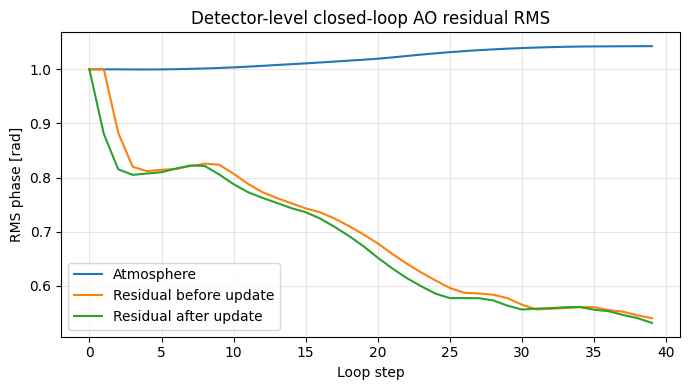

In [16]:
steps = np.arange(len(history["rms_after"]))

plt.figure(figsize=(7, 4))
plt.plot(steps, history["rms_atmosphere"], label="Atmosphere")
plt.plot(steps, history["rms_before"], label="Residual before update")
plt.plot(steps, history["rms_after"], label="Residual after update")
plt.xlabel("Loop step")
plt.ylabel("RMS phase [rad]")
plt.title("Detector-level closed-loop AO residual RMS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

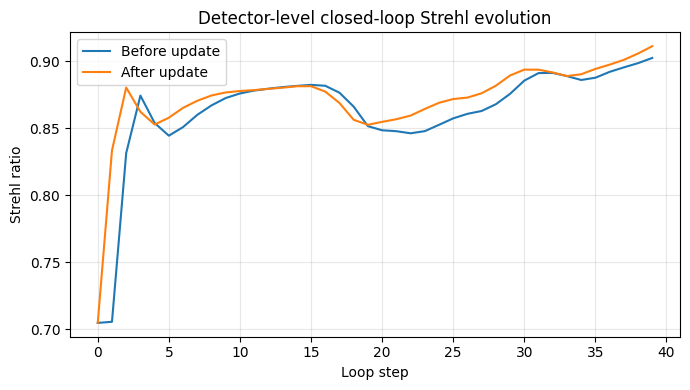

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(steps, history["strehl_before"], label="Before update")
plt.plot(steps, history["strehl_after"], label="After update")
plt.xlabel("Loop step")
plt.ylabel("Strehl ratio")
plt.title("Detector-level closed-loop Strehl evolution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

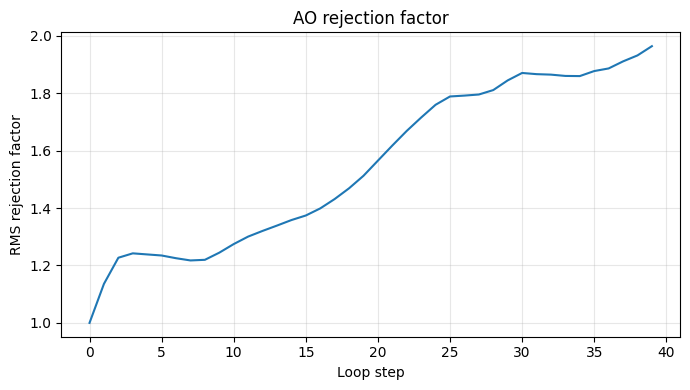

Median tail rejection factor: 1.87


In [18]:
rejection_factor = history["rms_atmosphere"] / history["rms_after"]

plt.figure(figsize=(7, 4))
plt.plot(steps, rejection_factor)
plt.xlabel("Loop step")
plt.ylabel("RMS rejection factor")
plt.title("AO rejection factor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median tail rejection factor: {np.median(rejection_factor[-10:]):.2f}")

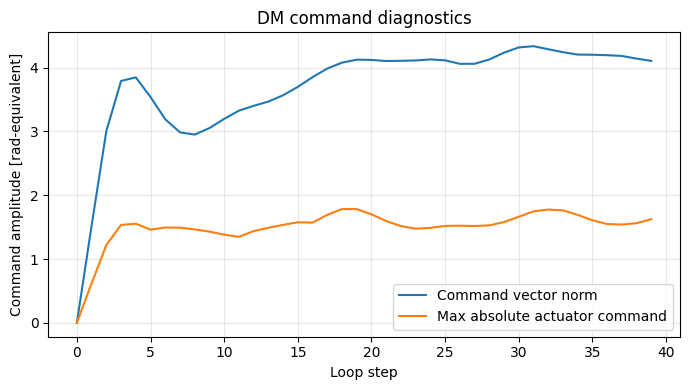

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(steps, history["command_norm"], label="Command vector norm")
plt.plot(steps, history["max_abs_command"], label="Max absolute actuator command")
plt.xlabel("Loop step")
plt.ylabel("Command amplitude [rad-equivalent]")
plt.title("DM command diagnostics")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The command diagnostics show whether the integrator remains stable. A steadily growing command norm would indicate command build-up or loop instability. The command leak term prevents slow drift by gradually forgetting old corrections.

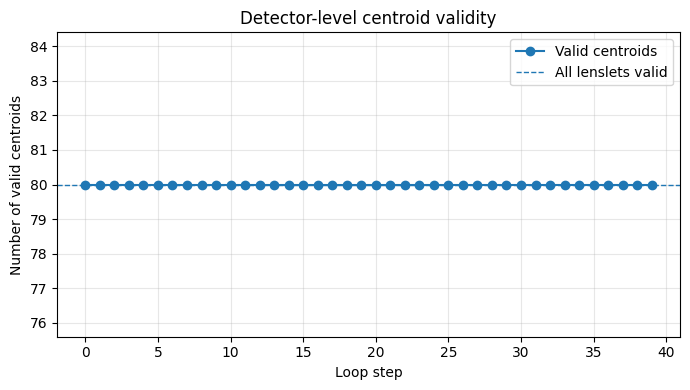

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(steps, history["valid_centroids"], "o-", label="Valid centroids")
plt.axhline(
    len(wfs_centers),
    linestyle="--",
    linewidth=1,
    label="All lenslets valid",
)
plt.xlabel("Loop step")
plt.ylabel("Number of valid centroids")
plt.title("Detector-level centroid validity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

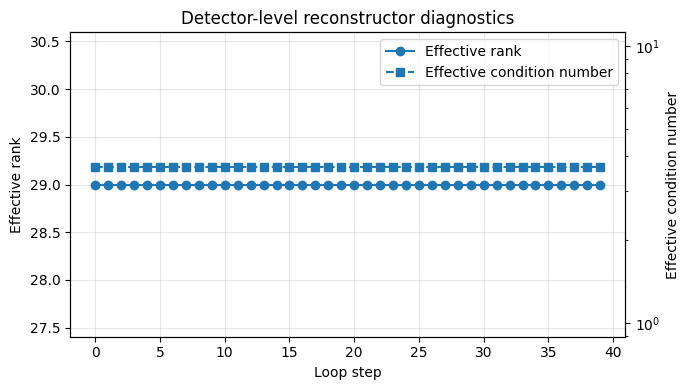

In [21]:
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(steps, history["rank"], "o-", label="Effective rank")
ax1.set_xlabel("Loop step")
ax1.set_ylabel("Effective rank")

ax2 = ax1.twinx()
ax2.plot(steps, history["cond_eff"], "s--", label="Effective condition number")
ax2.set_ylabel("Effective condition number")
ax2.set_yscale("log")

ax1.set_title("Detector-level reconstructor diagnostics")
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()


## 5. Visualize a corrected residual phase

The DM cannot remove all phase structure, especially if the atmospheric phase contains spatial frequencies beyond the actuator grid.  The residual is therefore a combination of fitting error, WFS noise, temporal/frozen-flow error, and numerical regularization.


Final atmosphere RMS:             1.0429 rad
Final closed-loop residual RMS:   0.5311 rad
Ideal static DM fitting RMS:      0.2801 rad


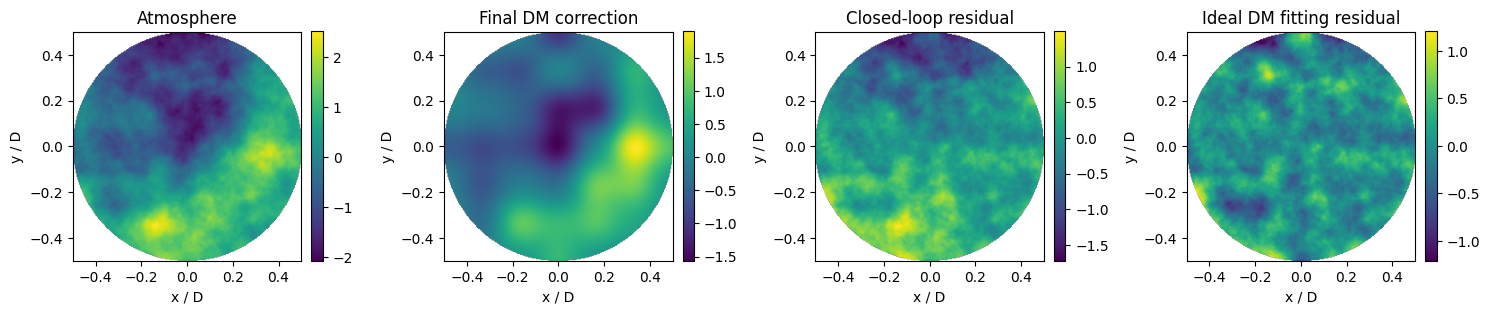

In [22]:
final = history["final_state"]

atm_final = final["atmosphere"]
dm_final = final["dm_after"]
res_final = final["residual_after"]

fit_commands_final, fit_dm_final, fit_res_final = fit_dm_to_phase(
    atm_final,
    influence_functions,
    pupil_mask,
    rcond=1e-6,
)

print(f"Final atmosphere RMS:             {rms(atm_final, pupil_mask):.4f} rad")
print(f"Final closed-loop residual RMS:   {rms(res_final, pupil_mask):.4f} rad")
print(f"Ideal static DM fitting RMS:      {rms(fit_res_final, pupil_mask):.4f} rad")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))

images = [
    atm_final,
    dm_final,
    res_final,
    fit_res_final,
]

titles = [
    "Atmosphere",
    "Final DM correction",
    "Closed-loop residual",
    "Ideal DM fitting residual",
]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
    ax.set_title(title)
    ax.set_xlabel("x / D")
    ax.set_ylabel("y / D")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

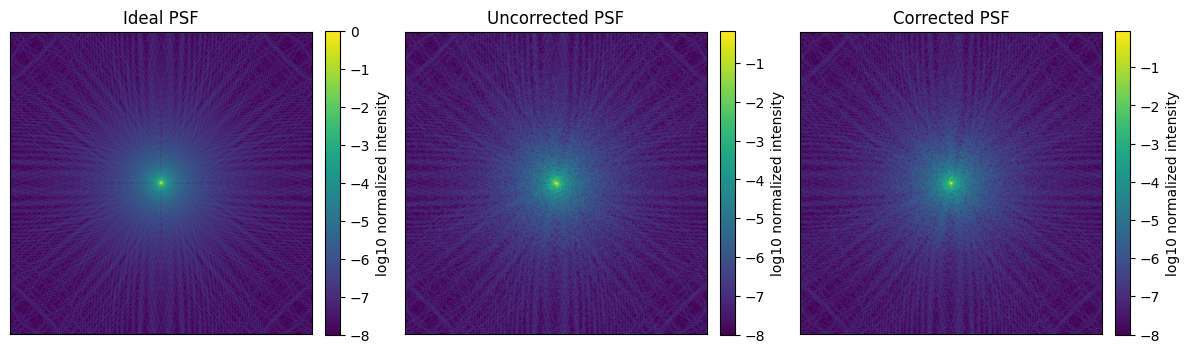

Uncorrected Strehl from PSF: 0.6831
Corrected Strehl from PSF:   0.9113
Corrected Strehl from helper:0.9113


In [23]:
ideal_phase = np.zeros_like(atm_final)

psf_ideal = compute_psf_from_phase(ideal_phase, pupil_mask, pad_factor=4)
psf_uncorrected = compute_psf_from_phase(atm_final, pupil_mask, pad_factor=4)
psf_corrected = compute_psf_from_phase(res_final, pupil_mask, pad_factor=4)

# Normalize all PSFs by the ideal diffraction-limited peak.
ideal_peak = psf_ideal.max()
psf_ideal_n = psf_ideal / ideal_peak
psf_uncorrected_n = psf_uncorrected / ideal_peak
psf_corrected_n = psf_corrected / ideal_peak

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))

for ax, psf, title in zip(
    axes,
    [psf_ideal_n, psf_uncorrected_n, psf_corrected_n],
    ["Ideal PSF", "Uncorrected PSF", "Corrected PSF"],
):
    im = ax.imshow(
        np.log10(np.maximum(psf, 1e-8)),
        origin="lower",
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
        label="log10 normalized intensity",
    )

plt.tight_layout()
plt.show()

print(f"Uncorrected Strehl from PSF: {psf_uncorrected_n.max():.4f}")
print(f"Corrected Strehl from PSF:   {psf_corrected_n.max():.4f}")
print(f"Corrected Strehl from helper:{strehl_ratio(res_final, pupil_mask, pad_factor=4):.4f}")


## 6. Loop-gain scan

A loop-gain scan is useful because AO control is not only a reconstruction problem; it is a dynamical control problem.  In this simple zero-delay model, high gains may still work reasonably well.  In a more realistic model with frame delay, wind speed, measurement noise, and DM dynamics, the stable gain range becomes narrower.


In [25]:
def detector_level_gain_scan(
    gains,
    base_kwargs,
    tail_length=10,
):
    """
    Run detector-level closed-loop simulations for different loop gains.
    """
    scan = {}

    for i, gain in enumerate(gains):
        h = run_detector_level_closed_loop_ao(
            gain=gain,
            seed=100 + i,
            **base_kwargs,
        )

        tail = h["rms_after"][-tail_length:]

        scan[gain] = {
            "history": h,
            "median_tail_rms": float(np.median(tail)),
            "final_rms": float(h["rms_after"][-1]),
            "final_strehl": float(h["strehl_after"][-1]),
            "median_tail_strehl": float(np.median(h["strehl_after"][-tail_length:])),
            "median_command_norm": float(np.median(h["command_norm"][-tail_length:])),
        }

    return scan


base_loop_kwargs = dict(
    phase_large=phase_large,
    pupil_mask=pupil_mask,
    X=X,
    Y=Y,
    influence_functions=influence_functions,
    response_matrix=B_det,
    reference=reference,
    lenslet_masks=lenslet_masks,
    wfs_centers=wfs_centers,
    n_steps=40,
    wind_shift_per_step=(2, 0),
    command_leak=0.01,
    delay_steps=1,
    photons=100_000,
    read_noise_e=read_noise_e,
    background_e=background_e,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
    threshold_fraction=centroid_threshold,
    subtract_minimum=subtract_minimum,
    detector_window_size=detector_window_size,
    rcond=1e-3,
    compute_strehl=True,
    strehl_pad_factor=4,
)

gains = [0.1, 0.2, 0.4, 0.7, 1.0]

scan = detector_level_gain_scan(
    gains,
    base_loop_kwargs,
    tail_length=10,
)

for gain, stats in scan.items():
    print(
        f"gain={gain:3.1f}  "
        f"median tail RMS={stats['median_tail_rms']:.4f} rad  "
        f"final RMS={stats['final_rms']:.4f} rad  "
        f"final Strehl={stats['final_strehl']:.4f}"
    )

gain=0.1  median tail RMS=0.6370 rad  final RMS=0.6016 rad  final Strehl=0.8527
gain=0.2  median tail RMS=0.5661 rad  final RMS=0.5457 rad  final Strehl=0.8978
gain=0.4  median tail RMS=0.5526 rad  final RMS=0.5288 rad  final Strehl=0.9110
gain=0.7  median tail RMS=0.5612 rad  final RMS=0.5222 rad  final Strehl=0.9101
gain=1.0  median tail RMS=3.3526 rad  final RMS=3.9861 rad  final Strehl=0.0335


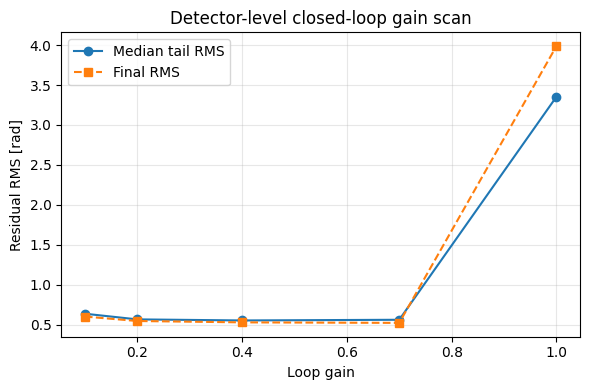

In [26]:
gain_arr = np.array(list(scan.keys()))
median_tail_rms = np.array([scan[g]["median_tail_rms"] for g in gain_arr])
final_rms = np.array([scan[g]["final_rms"] for g in gain_arr])
final_strehl = np.array([scan[g]["final_strehl"] for g in gain_arr])

plt.figure(figsize=(6, 4))
plt.plot(gain_arr, median_tail_rms, "o-", label="Median tail RMS")
plt.plot(gain_arr, final_rms, "s--", label="Final RMS")
plt.xlabel("Loop gain")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector-level closed-loop gain scan")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

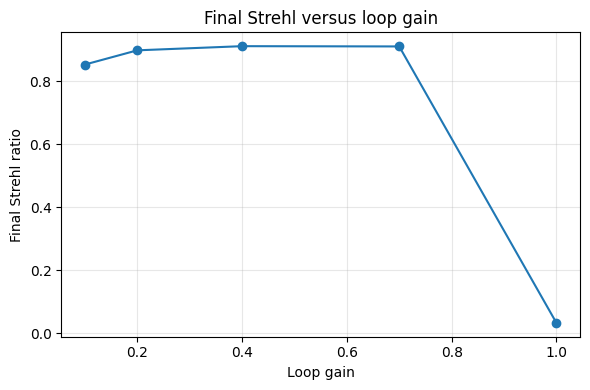

In [27]:
plt.figure(figsize=(6, 4))
plt.plot(gain_arr, final_strehl, "o-")
plt.xlabel("Loop gain")
plt.ylabel("Final Strehl ratio")
plt.title("Final Strehl versus loop gain")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
delays = [0, 1, 2, 3]
delay_scan = {}

for delay in delays:
    kwargs = dict(base_loop_kwargs)
    kwargs["delay_steps"] = delay

    h = run_detector_level_closed_loop_ao(
        gain=0.4,
        seed=200 + delay,
        **kwargs,
    )

    delay_scan[delay] = {
        "history": h,
        "median_tail_rms": float(np.median(h["rms_after"][-10:])),
        "final_strehl": float(h["strehl_after"][-1]),
    }

for delay, stats in delay_scan.items():
    print(
        f"delay={delay} frame(s)  "
        f"median tail RMS={stats['median_tail_rms']:.4f} rad  "
        f"final Strehl={stats['final_strehl']:.4f}"
    )

delay=0 frame(s)  median tail RMS=0.5570 rad  final Strehl=0.9143
delay=1 frame(s)  median tail RMS=0.5562 rad  final Strehl=0.9100
delay=2 frame(s)  median tail RMS=0.5642 rad  final Strehl=0.9026
delay=3 frame(s)  median tail RMS=0.7735 rad  final Strehl=0.7852


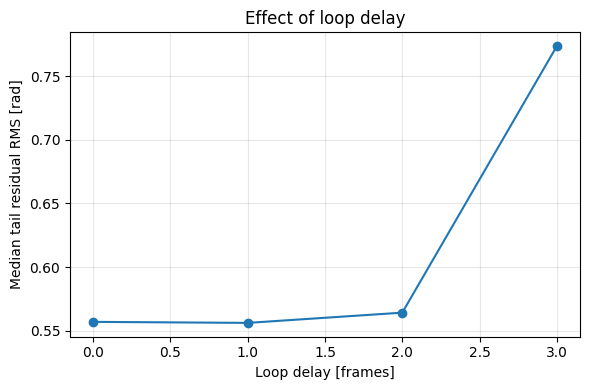

In [29]:
delay_arr = np.array(list(delay_scan.keys()))
delay_rms = np.array([delay_scan[d]["median_tail_rms"] for d in delay_arr])
delay_strehl = np.array([delay_scan[d]["final_strehl"] for d in delay_arr])

plt.figure(figsize=(6, 4))
plt.plot(delay_arr, delay_rms, "o-")
plt.xlabel("Loop delay [frames]")
plt.ylabel("Median tail residual RMS [rad]")
plt.title("Effect of loop delay")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

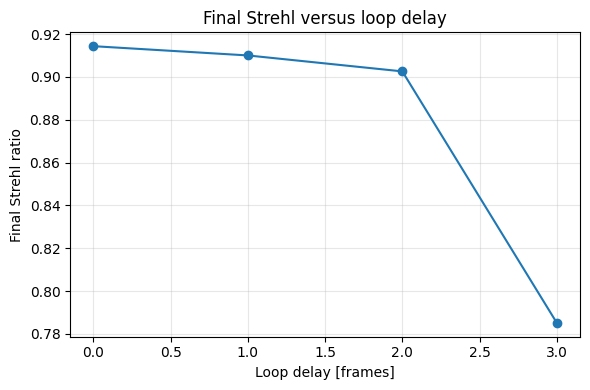

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(delay_arr, delay_strehl, "o-")
plt.xlabel("Loop delay [frames]")
plt.ylabel("Final Strehl ratio")
plt.title("Final Strehl versus loop delay")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

This notebook upgrades the closed-loop AO simulation from a geometric slope model to a detector-level Shack-Hartmann WFS model.

The WFS measurement is now obtained from simulated lenslet focal-plane spots. Detector effects such as finite photon count, read noise, centroid thresholding, and centroid estimation are included before the measurement is passed to the reconstructor. Therefore, the closed loop no longer assumes ideal analytic slopes.

The response matrix maps DM actuator commands to detector-level centroid shifts. The loop then repeatedly measures the residual wavefront, reconstructs an incremental DM command, and updates the DM through an integrator controller.

Several physically important effects are included:

- a large frozen-flow phase screen is cropped over time, avoiding artificial pupil-sized wrap-around;
- the WFS measurement is detector-level rather than geometric;
- a configurable loop delay is included;
- command leak prevents slow actuator drift;
- the final phase maps are taken directly from the actual stored loop state;
- the ideal static DM fitting limit is computed for comparison;
- PSF and Strehl diagnostics translate residual phase error into image quality;
- gain and delay scans show the dynamical behavior of the closed loop.

The final residual error should be interpreted as a combination of several terms:

```text
closed-loop residual
≈ DM fitting error
+ WFS detector noise
+ temporal error from frozen flow and delay
+ controller error
+ regularization / reconstruction error
```